# Energy Consumption Growth in the "AI Era"
#### _Exploratory Data Analysis by Nicolas Berredo_

## Research Questions

The Project targets to answer the following questions:

-	How has US energy consumption per capita increased after the “AI Boom” (2022)? 
-	How have projections for energy consumption changed as suddenly more data centers are being built across the country?
-	It is known that energy prices are constantly increasing. However, have energy prices in states with high concentrations of data centers (i.e. Virginia) increased above inflation rates?
---


## Motivation
Issues regarding energy consumption and technology have always been a topic in mainstream news outlets. Some years ago, for example, when Cryptocurrency, NFTs and Blockchain technologies were highly talked about, some issues regarding high energy and water consumption to maintain those structures also became a public debate.

However, in a somewhat unexpected way, another technology surfaced in a much more dramatic way. Since 2022, the quality and multifunctionality of AI and Chatbots have been on the rise, leading to more than half of the US population making daily use of these tools nowadays. This led to more energy consumption, with an average increase of 6.5% in the average cost of electricity for residential customers. However, it is still unclear how much of this was influenced by the construction of more data centers.

The U.S Energy Information Administration (EIA) releases energy production forecasts yearly, based on linear regression models. These, however, cannot predict abnormal events such as technological changes. It is estimated that 4.4% of national energy production goes towards data centers, with some states like Virginia reaching 25%. Therefore, it interests me to find out how the construction of AI datacenters has been shaping energy consumption and prices across the country.

---


## Data Setting

I will be using EIA’s energy dataset, which includes different metrics. I will use the following: 

-	Total energy consumption estimates per capita by end-use sector, annual (https://www.eia.gov/beta/states/data/dashboard/energy-indicators)
-	Average price of electricity to ultimate customers by end-use sector, monthly (https://www.eia.gov/beta/states/data/dashboard/energy-indicators)
-	Annual Energy Outlook 2019 and 2025 (https://www.eia.gov/outlooks/aeo/)

Data sheets are available, and the datasets include state-specific analysis. However, 3 issues may arise:

-	Some of the energy growth might still reflect post-COVID industrial rebound or cryptocurrency mining.
-	National outkast might not reflect the actual growth of AI as data centers are usually highly concentrated in Virginia, Texas, and Iowa.
-	The dataset might be affected by issues such as climate change or immigration (for data that is not related to population growth)
---


## Method
The project will be divided into 3 steps, each of which has its own function implementations

#### **Step 1: Energy consumption analysis**

- `load_eia_consumption(datafile)`  
Function returns a `DataFrame` comparing energy consumption in each year, including `sector` and `state` columns. I will test this function using a small `.xlsx` (for example, four states × four years) and confirm that the output `DataFrame` contains the correct columns (`year`, `state`, `sector`, `consumption`) and accurate numeric values.

- `group_consumption(df)`  
Function returns a `DataFrame` grouping consumption by states with high (`High-DC`) versus low amounts of data centers (`Low-DC`). To test this, I will use the previous dataset with known consumption totals for each group and check that the group averages match my manual calculations.

- `plot_eia_consumption(df, type)`  
Function returns a plot showing consumption comparisons between different sectors or state groups. `type` determines if the visualization is a sector comparison, a `relplot` by state, or a national trend line.

_How it connects to research questions:_  
If most states (or the national average) show a significant positive difference after 2022, it supports the hypothesis that U.S. energy consumption per capita increased following the AI boom.

---

#### **Step 2: Energy consumption forecast analysis**

- `load_eia_forecast(datafile)`  
Function returns a `DataFrame` containing energy consumption projections from different EIA Annual Outlook vintages (e.g., 2019 vs 2025), with `year` and predicted consumption columns. I will test this function using a small `.xlsx` and confirm that the output `DataFrame` contains the correct columns and accurate numeric values.

- `align_forecasts(df, forecast_past, forecast_new)`  
Function aligns both forecast datasets over overlapping years (e.g., 2025–2030) and calculates the difference in projected consumption for each year. This will be tested by verifying that it correctly matches overlapping years and that the computed differences equal the manual subtraction of the two projections.

- `plot_eia_forecast(df, type)`  
Function returns a plot comparing multiple forecast vintages.  
If `type="lines"`, plots both forecasts over time; if `type="delta"`, shows year-by-year differences in projected consumption.

_How it connects to research questions:_  
If the newer (2025) forecast consistently predicts higher consumption levels than the 2019 forecast for the same years, it indicates that energy consumption projections changed despite having the same past trends. This is likely in response to the rapid construction of AI data centers.

---

#### **Step 3: Energy price increase analysis**

- `load_eia_prices(datafile)`  
Function returns a `DataFrame` with `state`, `year`, `high_dc` (bool representing if they have a lot of data centers), `price_per_btu`, and `real_price` readjusted for inflation. I will test this function using a small `.xlsx` and confirm that the output `DataFrame` contains the correct columns and that `real_price` matches manual calculations using price readjustment with inflation.

- `group_prices(df)`  
Function returns a `DataFrame` grouping consumption by states with high versus low amounts of data centers. This will be tested by using a small sample where I can manually calculate the average price change for `High-DC` and `Low-DC` states, ensuring the function’s grouped averages match.

- `plot_price_trends(df)`  
Function returns a plot showing real electricity prices from 2019–2024, with lines for states with high and low data center density.

_How it connects to research questions:_  
If real electricity prices in `High-DC` states (like Virginia, Texas, and Iowa) increased more than inflation and faster than in `Low-DC` states, it supports the hypothesis that data center concentration has contributed to above-inflation electricity price growth after the AI boom.

---

## EDA Results

Below are some info for each dataset, according to its purpose/step. Length is in rows x columns. None of them have missing data.

**Consumption**

Dataset length: 2 of 52 x 65
Final dataframe length: 6656 rows x 4 columns

Variables of interest:

- `state` Can be important for later comparison considering states with high ammounts of data centers.
- `year` Important for year analysis before and after the AI boom
- `sector` Important for comparison between commercial sector and all sectors
- `consumption` Fundamental value for consumption change analysis

**Forecast**


Dataset length: 2 of 110 x 30
Final dataframe length: 122 rows x 3 columns

Variables of interest:

- `end_use` (connect to research questions)
- `year` Important for year analysis before and after the AI boom
- `consumption` Fundamental value for consumption forecast analysis

**Price**


Dataset length: 2 of 52 x 64
Final dataframe length: 5616 rows x 4 columns

Variables of interest:

- `state` Can be important for later comparison considering states with high ammounts of data centers.
- `year` Important for year analysis before and after the AI boom
- `sector` Important for comparison between commercial sector and all sectors
- `price_per_btu` Fundamental value for price change analysis


In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [46]:
def load_sector(datafile, sheet_name, focus_column):
    df = pd.read_excel(datafile, sheet_name = sheet_name, header=2)

    df = df.rename(columns={"State": "state"})
    df = df.melt(
        id_vars="state",
        var_name="year",
        value_name=focus_column
    )

    df = df[df["state"].notna() & df["year"].notna()]
    
    df["year"] = df["year"].astype(int)

    df["sector"] = sheet_name.split()[0].lower()

    return df[["state", "year", "sector", focus_column]]

def load_eia_consumption(datafile):
    """
    datafile: xlsx file with sectors
    """
    focus_column = 'consumption'
    
    df_commercial = load_sector(datafile, 'Commercial sector', focus_column)
    df_total = load_sector(datafile, 'Total consumption', focus_column)
    df_all = pd.concat([df_commercial, df_total], ignore_index=True)

    return df_all

In [47]:
def load_outlook(datafile, year, header, comp_indicator, total_indicator):
    df = pd.read_excel(datafile, header=header)
    computing = df[' Key Indicators and Consumption'] == comp_indicator
    total = df[' Key Indicators and Consumption'] == total_indicator

    df = df[computing | total].drop(df.columns[[0, -1]], axis=1).iloc[-2:].reset_index(drop=True)
    df = df.rename(columns={' Key Indicators and Consumption': 'end_use'})
    
    df.loc[0, "end_use"] = f"Computing ({year} Outlook)"
    df.loc[1, "end_use"] = f"Total Commercial ({year} Outlook)"
    
    df = df.melt(
        id_vars="end_use",
        var_name="year",
        value_name="consumption"
    )

    df["year"] = df["year"].astype(int)

    return df
    
def load_eia_forecast(data_old, data_new):
    df_new = load_outlook(
        datafile = data_new,
        year = 2025, 
        header = 9,
        comp_indicator = '   Computing 4/ 5/',
        total_indicator = '     Delivered Energy 8/'
    )
    df_old = load_outlook(
        datafile = data_old,
        year = 2019, 
        header = 12,
        comp_indicator = '   Computing',
        total_indicator = '     Delivered Energy'
    )
    
    df_all = pd.concat([df_old, df_new], ignore_index=True)
    return df_all

In [48]:
def load_eia_prices(datafile):
    """
    datafile: xlsx file with sectors
    """
    df = pd.read_csv(datafile, header=4)
    df_filtered = df[
        df["description"].str.contains("all sectors") | 
        df["description"].str.contains("commercial")
        ]
        
    df_filtered = df_filtered.drop(columns = ["units", "source key"])
    
    df_filtered =df_filtered.melt(
        id_vars = "description",
        var_name = "month_year",
        value_name = "cents_per_kwh"
    )
    
    df_filtered = df_filtered[df_filtered["month_year"].str.contains("Dec")].reset_index(drop=True)
    
    description = df_filtered["description"].str.split(" : ")
    df_filtered["sector"] = description.str[-1]
    df_filtered["state"] = description.str[0]
    
    df_filtered["year"] = df_filtered["month_year"].str.split(" ").str[-1].astype(int)
    df_filtered = df_filtered.drop(columns = ["month_year", "description"])
    
    df_filtered["cents_per_kwh"] = df_filtered["cents_per_kwh"].astype(float)
    
    
    return df_filtered[["state", "sector", "year", "cents_per_kwh"]] #order change

In [49]:
df_consumption = load_eia_consumption('use_tot_sector.xlsx')
df_forecast = load_eia_forecast('outlook_2019.xlsx', 'outlook_2025.xlsx')
prices_df = load_eia_prices('Average_retail_price_of_electricity.csv')

print(df_consumption)
print(df_forecast)
print(prices_df)

     state  year      sector  consumption
0       AK  1960  commercial         6592
1       AL  1960  commercial        53463
2       AR  1960  commercial        34197
3       AZ  1960  commercial        61977
4       CA  1960  commercial       401576
...    ...   ...         ...          ...
6651    WA  2023       total      1602662
6652    WI  2023       total      1656177
6653    WV  2023       total       832806
6654    WY  2023       total       499766
6655    US  2023       total     93557489

[6656 rows x 4 columns]
                             end_use  year  consumption
0           Computing (2019 Outlook)  2017     8.907717
1    Total Commercial (2019 Outlook)  2017     1.021883
2           Computing (2019 Outlook)  2018     9.153907
3    Total Commercial (2019 Outlook)  2018     0.992913
4           Computing (2019 Outlook)  2019     9.136508
..                               ...   ...          ...
117  Total Commercial (2025 Outlook)  2048     1.665758
118         Computing (

In [50]:
high_dc_states = ["VA","CA","TX","IL","AZ","GA","NJ","NY","WA","OR"]
high_dc_names = ["Virginia", "California", "Texas", "Illinois", "Arizona", "Georgia", "New Jersey", "New York", "Washington", "Oregon"]

In [51]:
def group_consumption(df, col = "consumption"):
    groups = []
    for state in df["state"]:
        if state in high_dc_states:
            groups.append("high_dc")
        elif state == "US":
            groups.append("nationwide")
        else:
            groups.append("low_dc")
    df["group"] = groups
    return df.groupby(["group", "year"])[col].sum().reset_index()

In [52]:
def align_forecasts(df):
    df = df.copy()
    df["outlook"] = df["end_use"].str.extract(r"\((\d{4}) Outlook\)")

    df["end_use_clean"] = (
        df["end_use"]
        .str.replace(r"\s*\(\d{4} Outlook\)", "", regex=True)
    )

    # Pivot so both forecasts are side-by-side
    aligned = df.pivot(
        index=["year", "end_use_clean"],
        columns="outlook",
        values="consumption"
    ).reset_index()
    
    aligned = aligned.rename(columns={
        "2019": "consumption_2019",
        "2025": "consumption_2025"
    })
    aligned["delta"] = (
        aligned["consumption_2025"] - aligned["consumption_2019"]
    )

    return aligned

In [53]:
def build_us_price_index(df_infl_raw):
    # Filter to USA only
    df_us = df_infl_raw[df_infl_raw["Country Code"] == "USA"].copy()

    year_cols = [c for c in df_us.columns if c.isdigit()]
    
    us_long = df_us.melt(
        id_vars=["Country Name", "Country Code"],
        value_vars=year_cols,
        var_name="year",
        value_name="inflation_pct"
    )
    us_long["year"] = us_long["year"].astype(int)
    
    us_long = us_long.dropna(subset=["inflation_pct"]).sort_values("year")
    
    us_long["inflation"] = us_long["inflation_pct"].astype(float) / 100.0
    us_long["price_index"] = (1 + us_long["inflation"]).cumprod()
    
    return us_long[["year", "price_index"]]


def calculate_real_prices(df_prices, infl_index_df, base_year=2024):
    df_prices = df_prices.sort_values("year").reset_index(drop=True)
    
    index_by_year = infl_index_df.set_index("year")["price_index"].to_dict()
    base_idx = index_by_year[base_year]
    
    real_prices = []
    for _, row in df_prices.iterrows():
        year = row["year"]
        price = row["cents_per_kwh"]
        idx_t = index_by_year[year]
        real_price = price * (base_idx / idx_t)
        real_prices.append(real_price)
    
    return real_prices

def group_prices(prices_df, df_infl_raw):
    infl_index_df = build_us_price_index(df_infl_raw)
    prices_real = prices_df.copy().sort_values("year").reset_index(drop=True)

    prices_real["real_price_2024"] = calculate_real_prices(
        prices_real, infl_index_df, base_year=2024
    )
    
    groups = []
    for state in prices_real["state"]:
        if state in high_dc_names:
            groups.append(f"high_dc")
        elif state == "United States":
            groups.append("nationwide")
        else:
            groups.append("low_dc")
    prices_real["group"] = prices_real["sector"].str.cat(groups, sep=" - ")
    
    df_grouped = (
        prices_real.groupby(["group", "year"])["real_price_2024"]
           .mean()
           .reset_index()
    )
    
    return df_grouped

In [54]:
df_infl = pd.read_csv("inflation_over_years.csv")

df_consump_grouped = group_consumption(df_consumption)
df_aligned = align_forecasts(df_forecast)
df_prices_grouped = group_prices(prices_df, df_infl)

df_consump_grouped
df_aligned
df_prices_grouped

,group,year,real_price_2024
0,all sectors - high_dc,2001,13.324099
1,all sectors - high_dc,2002,13.121305
2,all sectors - high_dc,2003,13.009099
3,all sectors - high_dc,2004,12.890776
4,all sectors - high_dc,2005,13.996934
...,...,...,...
145,commercial - nationwide,2021,12.907826
146,commercial - nationwide,2022,13.162597
147,commercial - nationwide,2023,12.601022
148,commercial - nationwide,2024,12.640000


In [55]:
# 1) CONSUMPTION PLOTS
def plot_eia_consumption(df_consumption, df_consump_grouped):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=False)

    # Consumption - 1: US commercial vs total
    sns.lineplot(
        data=df_consumption[df_consumption["state"] == "US"],
        x="year", y="consumption", hue="sector", marker="o", ax=axes[0]
    )
    axes[0].set_title("U.S. Energy Consumption Over Time\n(Commercial vs Total)")
    axes[0].set_ylabel("Consumption (Billion BTU)")
    axes[0].set_xlabel("Year")
    axes[0].legend(title="Sector")

    # Consumption - 2: high_dc vs low_dc vs nationwide
    sns.lineplot(
        data=df_consump_grouped,
        x="year", y="consumption", hue="group", marker="o", ax=axes[1]
    )
    axes[1].set_title("Energy Consumption Over Time\nby Data Center Intensity")
    axes[1].set_ylabel("Consumption (Billion BTU)")
    axes[1].set_xlabel("Year")
    axes[1].legend(title="Group")

    fig.tight_layout()
    plt.show()

In [56]:
# 2) FORECAST PLOTS
def plot_eia_forecast(df_forecast, df_aligned):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=False)

    # Forecast - 1: raw forecasts
    sns.lineplot(
        data=df_forecast,
        x="year", y="consumption", hue="end_use", marker="o", ax=axes[0]
    )
    axes[0].set_title("EIA Forecast: Computing vs Total Commercial")
    axes[0].set_ylabel("Projected Consumption (Quadrillion BTU)")
    axes[0].set_xlabel("Year")
    axes[0].legend(title="End Use")

    # Forecast - 2: deltas between 2025 and 2019 outlooks
    sns.lineplot(
        data=df_aligned,
        x="year", y="delta", hue="end_use_clean", marker="o", ax=axes[1]
    )
    axes[1].axhline(0, linestyle="--", linewidth=1, color="gray")
    axes[1].set_title("Change in EIA Forecasts:\n2025 Outlook vs 2019 Outlook")
    axes[1].set_ylabel("Δ Projected Consumption (Quadrillion BTU)")
    axes[1].set_xlabel("Year")
    axes[1].legend(title="End Use")

    fig.tight_layout()
    plt.show()

In [57]:
# 3) PRICE PLOTS
def plot_price_trends(prices_df, df_prices_grouped):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=False)

    # Price - 1: nominal US prices by sector
    sns.lineplot(
        data=prices_df[prices_df["state"] == "United States"],
        x="year", y="cents_per_kwh", hue="sector", marker="o", ax=axes[0]
    )
    axes[0].set_title("U.S. Electricity Price per Kwh Over Time")
    axes[0].set_ylabel("Price (Cents per Kwh)")
    axes[0].set_xlabel("Year")
    axes[0].legend(title="Sector")

    # Price - 2: real prices (2024 dollars) for high_dc vs low_dc
    
    sns.lineplot(
        data=df_prices_grouped[
            df_prices_grouped["group"].str.contains("high_dc") |
            df_prices_grouped["group"].str.contains("low_dc")],
        x="year", y="real_price_2024", hue="group", marker="o", ax=axes[1]
    )
    axes[1].set_title("Real Electricity Price per Kwh Over Time\n(2024 Dollars)")
    axes[1].set_ylabel("Real Price (Cents per Kwh, 2024 = base year)")
    axes[1].set_xlabel("Year")
    axes[1].legend(title="Group")

    fig.tight_layout()
    plt.show()

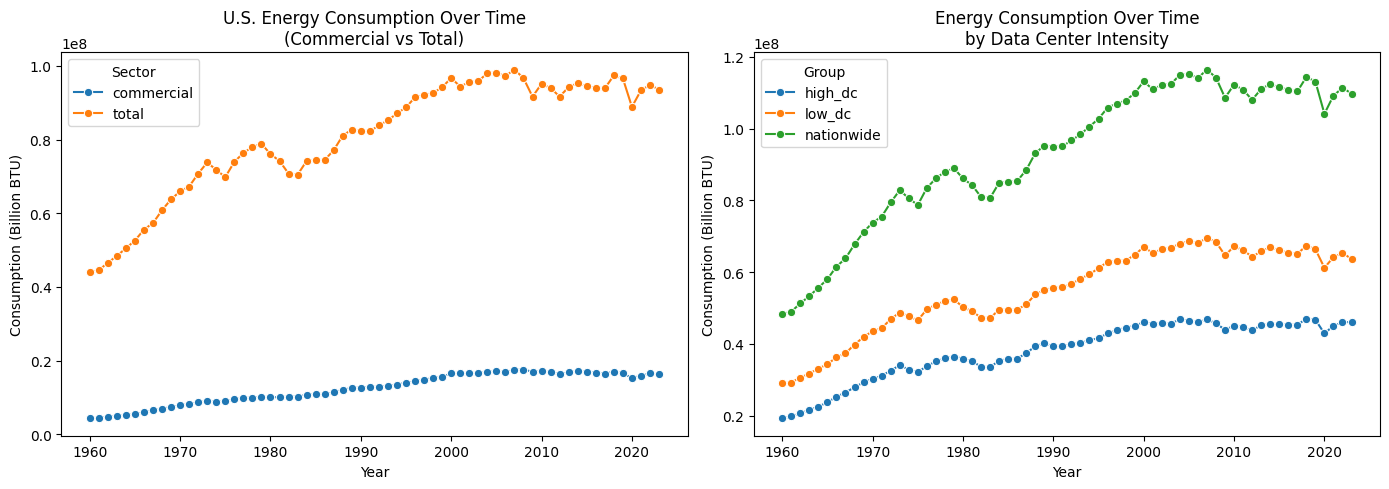

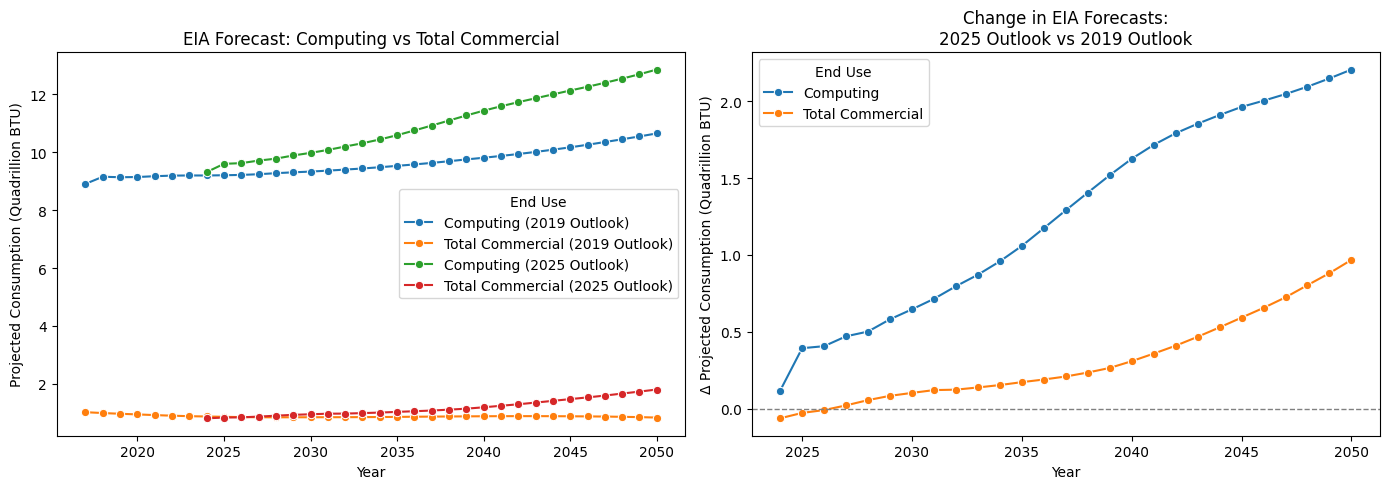

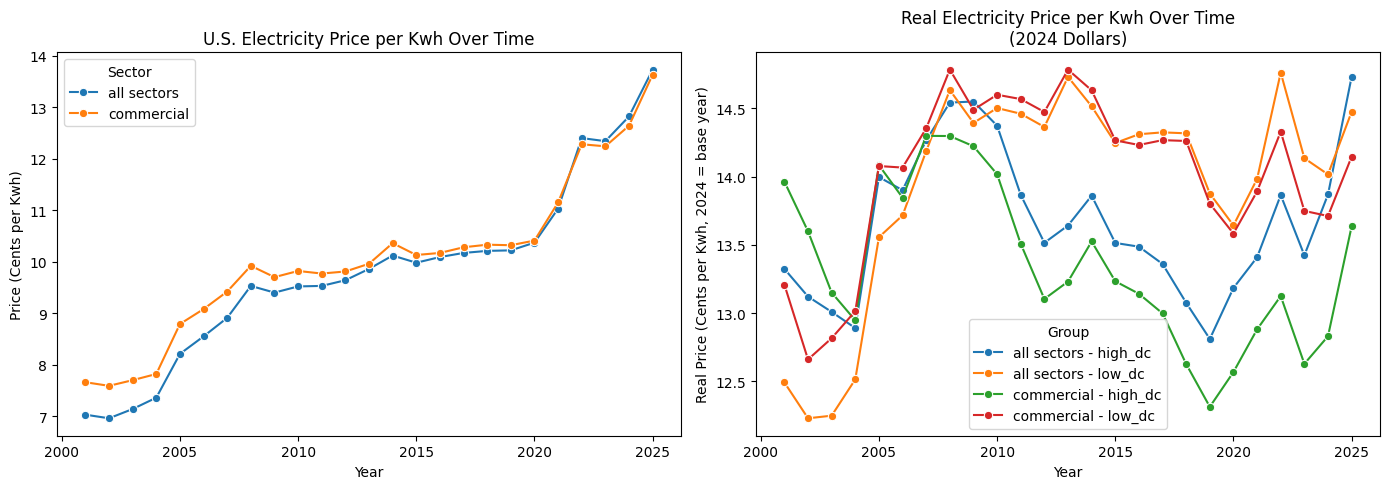

In [58]:
plot_eia_consumption(df_consumption, df_consump_grouped)
plot_eia_forecast(df_forecast, df_aligned)
plot_price_trends(prices_df, df_prices_grouped)

## Results
For better analysis, bellow is each question and my findings throughout this project.

-	How has US energy consumption per capita increased after the “AI Boom” (2022)? 

US energy consumption per capita has has not increased that significantly after the boom. However, high dc density states have kept a more steady consumption between 2022 and 2023 than low dc density states. This, however, is not by an ammount that significant. This could be due to the dataset only having numbers untill 2023, while lacking on the more "intense" and recent boom in 2024 and 2025.

-	How have projections for energy consumption changed as suddenly more data centers are being built across the country?

Projections have changed a lot. While total consumption for commercial ends will decrease or not change that much, the projections for computing have drastically changed, with a difference of projected consumption of 1 quadrillion BTU in 2050 in the most recent forecasts when compared to the 2019 analysis. This shows that the AI boom clearly changed energy consumption projections exclusevely for computing.


-	It is known that energy prices are constantly increasing. However, have energy prices in states with high concentrations of data centers (i.e. Virginia) increased above inflation rates?

High dc concentration states actually have a lower average price per btu than low dc concentration states. This could be due to corporate lobby, public policies to attract Big Tech companies, or just general political bias.

---

## Impact and Limitation

The main limitation of this project is the year scope of some datasets, with ranges only going to 2023. Also, it does not prove energy price differences after the AI boom, or current energy increase. It does, however, indicate an increase in energy consumption for Computing, which could lead to more infrastructure demand for energy production.

## Challenge Goals
I planned to meet the following challenge goals during my project:

-	Multiple datasets: I will meet this goal because my project consists of 4 different datasets, some of which include both national and state analysis. Those are: energy consumption per capita by end-use sector, price of electricity to ultimate customers by end-use sector, and annual energy outlook (forecasts) from 2019 and 2025.
-	Challenge Goal 2: Statistical Hypothesis Testing: My project will also meet this goal because I plan to formally test hypotheses about whether states with higher concentrations of data centers have experienced energy price increases above inflation rates. I will also analyze whether post-2022 energy consumption growth per capita differs significantly from pre-2022 trends. In addition, I will, for example, compare data from two different groups of states by data center density, consider the economic context, and pre-register a hypothesis to reduce bias. This ensures more evidence-based analysis.

With the adition of an inflation dataset, I believe to have expanded the multiple datasets goal.
My data still does not completely prove some of the questions made and does not include other external variables as already described. However, it still correlates to a hypothesis and proves/disproves some thoughts previously made.

## Plan Evaluation

My goals for consumption were overall met. I have analyzed that commercial consumption had a sudden increase after the AI boom. Furthermore, the forecast for energy use in the Computing field increased substantially, with new forecasts indicating a future increase while past ones indicating a decrease. Price, however, has yet to be analyzed more deeply to check for correlations. The recent national rise does not necessarily indicate that it is due to AI.

## Testing

I used smaller data files and doctests with simillar structure to the real datasets. I trust my results because I calculated how many rows the dataframes should have, and they all match my expectations. For example, for the consumption dataframe, I calculated that it should have 6656 rows (52 places * 63 years * sectors), which matched what I got.